## <span style="color:#db7d60">Purpose</span>

The goal of this notebook is to organize all the figures needed for publication 1 result 2, the dataset size vs. validation loss.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
import json
import pickle
import datetime
from collections import Counter, defaultdict
from types import SimpleNamespace
from itertools import islice
from pathlib import Path
# Math
import math
import numpy as np
import pandas as pd
from numba import njit, float64, types
from numba.experimental import jitclass
from numba.typed import Dict
from scipy.signal import savgol_filter
from numerize import numerize
# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, FuncFormatter, MaxNLocator
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from particle import Particle
import vector
import jetnet
import jetnet.evaluation

# pUtil needs to be loaded from the root directory
parent_dir = Path().resolve().parent
root_dir = Path().resolve().parent.parent
sys.path.insert(0, str(parent_dir))
sys.path.insert(0, str(root_dir))

# particleGPT
import pUtil
import data_manager
from analysis_common import *
import analysis_v2 as analv2

#### Set basic themeing and display options for optimal display of information

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# Set use_text=True if a latex installation is avaliable.
analv2.plotting_v2.set_publication_style(base_fontsize=10, dpi=100, save_dpi=600, use_tex=False)

# We want larger fonts for these figures
analv2.plotting_v2.fontsize_ticks = 14
analv2.plotting_v2.fontsize_axes_labels = 14

<Figure size 640x480 with 0 Axes>

## <span style="color:#db7d60">Setup</span>

In [3]:
# all models
all_models_dict = {
    'model_exp11_100k_lr1': '16.6M - 20M',
    'model_exp11_100k_lr1_tp6': '16.6M - 39M',
    'model_exp11_100k_lr1_tp4': '16.6M - 70M',
    'model_exp11_100k_lr1_tp3': '16.6M - 108M',
    'model_exp11_500k_lr1': '83M - 20M',
    'model_exp11_500k_lr1_tp4': '83M - 79M',
    'model_exp11_500k_lr1_tp6': '83M - 39M',
    'model_exp11_1M_lr1': '166M - 20M',
    'model_exp11_1M_lr1_tp3': '166M - 108M', 
    'model_exp11_1M_lr1_tp4': '166M - 76M',
    'model_exp11_1M_lr1_tp5': '166M - 611M', 
    'model_exp11_1M_lr1_tp6': '166M - 39M', 
    'model_exp11_2M_lr1': '332M - 20M',
    'model_exp11_2M_lr1_tp3': '332M - 108M',
    'model_exp11_2M_lr1_tp4': '332M - 76M',
    'model_exp11_2M_lr1_tp5': '332M - 611M',
    'model_exp11_2M_lr1_tp6': '332M - 39M',
    'model_exp11_5M_lr1': '830M - 20M',
    'model_exp11_5M_lr1_tp2': '830M - 208M',
    'model_exp11_5M_lr1_tp3': '830M - 108M',
    'model_exp11_5M_lr1_tp4': '830M - 76M',
    'model_exp11_5M_lr1_tp6': '830M - 39M',
    'model_10M_9_exp9_vdimlr_1': '1.47B - 20M',
    'model_exp11_9M_lr1_tp2': '1.47B - 208M',
    'model_exp11_9M_lr1_tp3': '1.47B - 108M',
    'model_exp11_9M_lr1_tp4': '1.47B - 76M',
    'model_exp11_9M_lr1_tp6': '1.47B - 39M',
    'model_exp11_9M_lr1_tp5': '1.47B - 611M',
    'model_exp11_22M_lr1_tp1': '3.8B - 20M',
    'model_exp11_22M_lr1_tp2': '3.8B - 208M',
    'model_exp11_22M_lr1_tp3': '3.8B - 108M',
    'model_exp11_22M_lr1_tp4': '3.8B - 76M',
    'model_exp11_22M_lr1_tp6': '3.8B - 39M',
    'model_exp11_22M_lr1_tp5': '3.8B - 611M',
    'model_exp11_45M_lr1_tp1': 'N/A B - 20M',
    'model_exp11_45M_lr1_tp6': 'N/A B - 39M',
    'model_exp11_45M_lr1_tp4': 'N/A B - 76M',
    'model_exp11_45M_lr1_tp3': 'N/A B - 108M',
    'model_exp11_45M_lr1_tp2': 'N/A B - 208M',
    'model_exp11_45M_lr1_tp5': 'N/A B - 611M'
}

model_names_all = list(all_models_dict.keys())
df = analv2.tables.get_default_df(model_names_all)

# ---- Best model for each dataset size ----
idx_dataset = df.groupby("num_train_tokens")["min_saved_val_loss"].idxmin()
best_model_names_dataset_size = df.loc[idx_dataset, "model_name"].tolist()

# ---- Best model for each parameter count ----
idx_params = df.groupby("num_params")["min_saved_val_loss"].idxmin()
best_model_names_num_params = df.loc[idx_params, "model_name"].tolist()

print("Best per dataset size:")
print(best_model_names_dataset_size)

print("\nBest per num_params:")
print(best_model_names_num_params)

Best per dataset size:
['model_exp11_100k_lr1_tp6', 'model_exp11_500k_lr1_tp6', 'model_exp11_1M_lr1_tp3', 'model_exp11_2M_lr1_tp6', 'model_exp11_5M_lr1_tp6', 'model_exp11_9M_lr1_tp6', 'model_exp11_22M_lr1_tp2', 'model_exp11_45M_lr1_tp4']

Best per num_params:
['model_exp11_5M_lr1', 'model_exp11_22M_lr1_tp6', 'model_exp11_22M_lr1_tp4', 'model_exp11_22M_lr1_tp3', 'model_exp11_22M_lr1_tp2', 'model_exp11_22M_lr1_tp5']


## <span style="color:#db7d60">Figure 1</span>

Figure 1 from the kaplan paper

In [4]:
model_names_dataset_size = best_model_names_dataset_size
model_names_model_size = best_model_names_num_params
model_names_compute = model_names_all

df_dataset_size = analv2.tables.get_default_df(model_names_dataset_size)
df_dataset_size["num_params_label"] = df_dataset_size["num_params"].map(lambda x: f"{x/1e6:.0f}M")
df_model_size = analv2.tables.get_default_df(model_names_model_size)
df_model_size["num_params_label"] = df_model_size["num_params"].map(lambda x: f"{x/1e6:.0f}M")
df_compute = analv2.tables.get_default_df(model_names_compute)
df_compute["num_params_label"] = df_compute["num_params"].map(lambda x: f"{x/1e6:.0f}M")
df_compute["compute"] = df_compute["num_params"] * df_compute["batch_size"] * df_compute["iters_saved"]

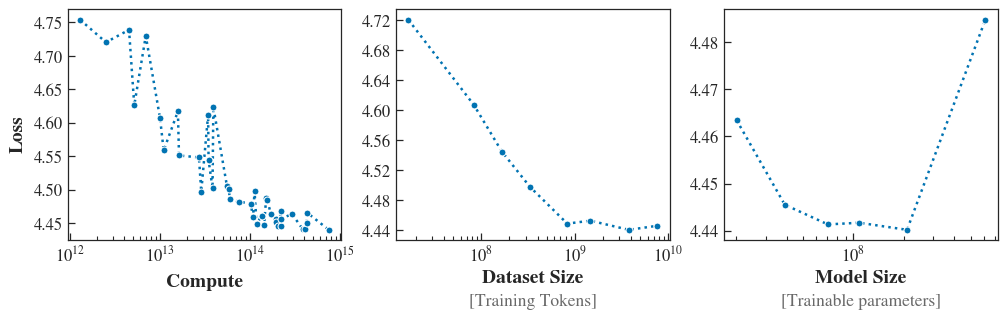

In [5]:
analv2.plotting_v2.fontsize_ticks = 12
analv2.plotting_v2.fontsize_axes_labels = 14

fig_cdp, axes = plt.subplots(1, 3, figsize=(12, 3))
ax_c, ax_d, ax_p = axes

# Set y-axis label on the left-most graph since all y-axes are the same
ax_c.text(
    -0.18, 0.4, "Loss", transform=ax_c.transAxes, rotation='vertical',
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)

# ===== Loss vs. Compute =====

sns.lineplot(
    ax=ax_c,
    data=df_compute, x="compute", y="min_saved_val_loss",
    marker="o", estimator=None, linestyle=':'
)
ax_c.set_xlabel("")
ax_c.set_ylabel("")
ax_c.set_xscale("log")
ax_c.text(
    0.5, -0.18, "Compute", transform=ax_c.transAxes,
    ha="center", va='center', fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)

# ===== Loss vs. Dataset Size =====

sns.lineplot(
    ax=ax_d,
    data=df_dataset_size, x="num_train_tokens", y="min_saved_val_loss",
    marker="o", estimator=None, linestyle=':'
)
ax_d.set_xlabel("")
ax_d.set_ylabel("")
ax_d.set_xscale("log")
ax_d.text(
    0.5, -0.18, "Dataset Size", transform=ax_d.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
ax_d.text(
    0.5, -0.28, "[Training Tokens]", transform=ax_d.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels * 0.9, color="dimgray"
)

# ===== Loss vs. Model Size =====

sns.lineplot(
    ax=ax_p,
    data=df_model_size, x="num_params", y="min_saved_val_loss",
    marker="o", estimator=None, linestyle=':'
)
ax_p.set_xlabel("")
ax_p.set_ylabel("")
ax_p.set_xscale("log")
ax_p.text(
    0.5, -0.18, "Model Size", transform=ax_p.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
ax_p.text(
    0.5, -0.28, "[Trainable parameters]", transform=ax_p.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels * 0.9, color="dimgray"
)

for ax in axes:
    ax.tick_params(axis='both', labelsize=analv2.plotting_v2.fontsize_ticks)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax_p.yaxis.set_major_locator(MaxNLocator(nbins=6))

plt.show()

In [6]:
fig_cdp.savefig("figures_export/png/pub_1_r2_cdp.png", bbox_inches='tight')
fig_cdp.savefig("figures_export/pdf/pub_1_r2_cdp.pdf", bbox_inches='tight')

## <span style="color:#db7d60">Figure 2</span>

Figure 4 from the kaplan paper

In [7]:
model_names_md_sizes = model_names_all
df_md_sizes = analv2.tables.get_default_df(model_names_md_sizes)
df_md_sizes["compute"] = df_md_sizes["num_params"] * df_md_sizes["batch_size"] * df_md_sizes["iters_saved"]

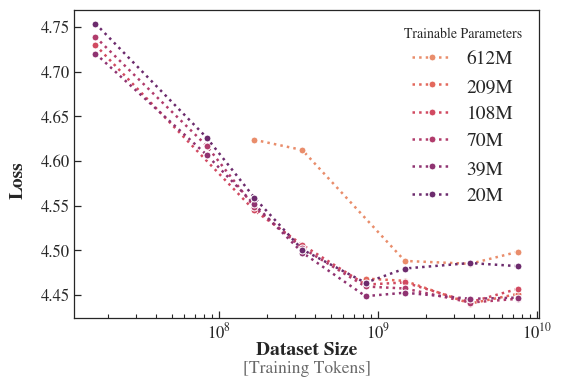

In [8]:
df_md_sizes = df_md_sizes[["model_name", "iters_saved", "min_saved_val_loss", "num_train_tokens", "num_params"]].copy()
df_md_sizes["num_params_label"] = df_md_sizes["num_params"].map(lambda x: f"{x/1e6:.0f}M")

order = (df_md_sizes.sort_values("num_params")["num_params_label"].drop_duplicates().iloc[::-1])

fig_dp_all, axes = plt.subplots(1, 1, figsize=(6, 4))
ax_md = axes

sns.lineplot(
    ax=ax_md,
    data=df_md_sizes, x="num_train_tokens", y="min_saved_val_loss", hue="num_params_label", hue_order=order,
    palette="flare", marker="o", estimator=None, linestyle=':'
)
ax_md.set_xlabel("")
ax_md.set_ylabel("")

# y-label
ax_md.text(
    -0.12, 0.4, "Loss", transform=ax_md.transAxes, rotation='vertical',
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
# x-label
ax_md.text(
    0.5, -0.12, "Dataset Size", transform=ax_md.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels, fontweight="bold"
)
ax_md.text(
    0.5, -0.18, "[Training Tokens]", transform=ax_md.transAxes,
    ha="center", fontsize=analv2.plotting_v2.fontsize_axes_labels * 0.9, color="dimgray"
)

ax_md.legend(title="Trainable Parameters", fontsize=analv2.plotting_v2.fontsize_legend)
ax_md.set_xscale("log")

plt.xticks(fontsize=analv2.plotting_v2.fontsize_ticks)
plt.yticks(fontsize=analv2.plotting_v2.fontsize_ticks)
plt.show()

In [9]:
fig_dp_all.savefig("figures_export/png/pub_1_r2_dp_all.png", bbox_inches='tight')
fig_dp_all.savefig("figures_export/pdf/pub_1_r2_dp_all.pdf", bbox_inches='tight')

## <span style="color:#db7d60">Figure 3</span>

Kinematic reconstructions for models with significant variation in vocab size (all particles).

For this, we have chosen two models to showcase: `model_10M_9_exp9_vdimlr_1` (14.7k tokens) and `model_10M_12_inclrrestarts_3` (1.9k tokens).

In [10]:
models_to_compare = ['model_10M_9_exp9_vdimlr_1', 'model_10M_12_inclrrestarts_3']

real_verbose_data = data_manager.load_verbose_dataset(
    pUtil.get_model_preparation_dir(models_to_compare[0]) / "real_verbose_test_particles.csv",
    pad_token=np.nan
)

gen_verbose_data_dict = {}
for mn in models_to_compare:
    sampled_verbose_data = data_manager.load_verbose_dataset(
        pUtil.get_latest_sampling_dir(mn) / "untokenized_samples_verbose.csv",
        pad_token=np.nan
    )
    gen_verbose_data_dict[mn] = sampled_verbose_data

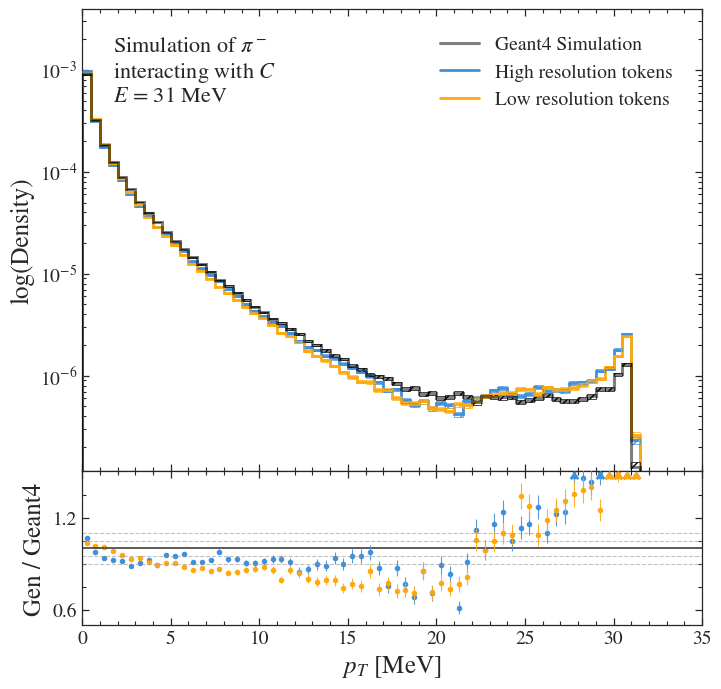

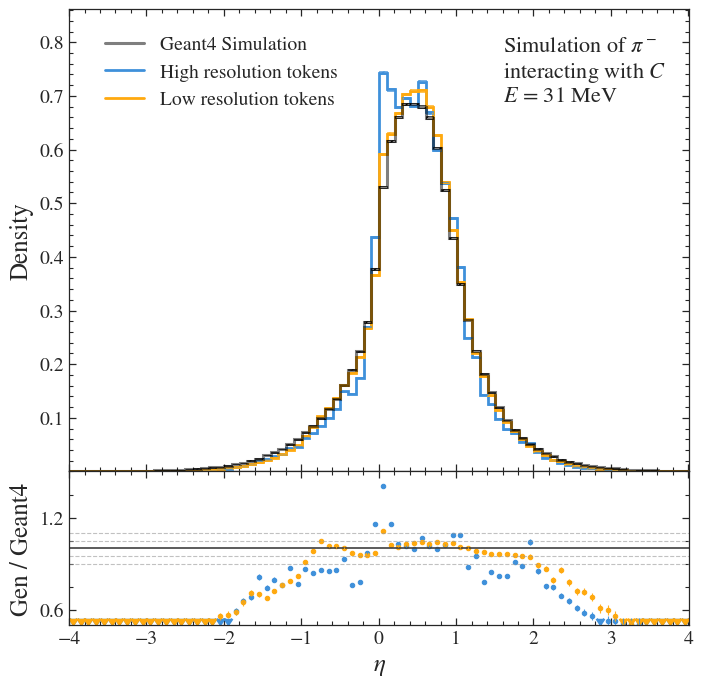

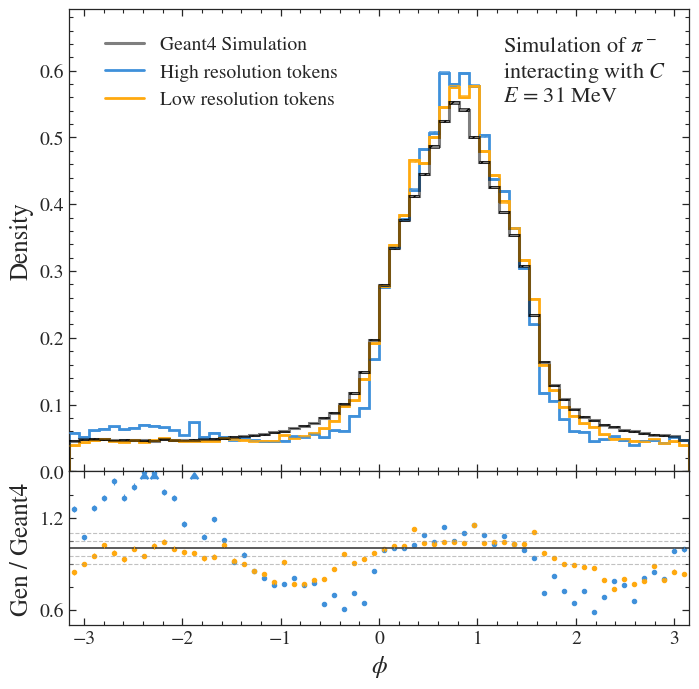

In [22]:
analv2.plotting_v2.fontsize_ticks = 14
analv2.plotting_v2.fontsize_axes_labels = 18

all_columns = ["pt", "eta", "phi"]
models_legend_titles = ['Geant4 Simulation', 'High resolution tokens', 'Low resolution tokens']

label_text = r"Simulation of $\pi^-$" "\n" "interacting with $C$" "\n" r"$E$ = 31 MeV"

cn_data_dict = {}
for column_name in all_columns:
    # analysis_v2.dataset provides methods to easily extract a single column for analysis
    gen_data_dict = {}
    pdata_real = analv2.dataset.extract_single_column_for_analysis(real_verbose_data, column_name, return_only_leading=False)
    for mn in models_to_compare:
        pdata_gen = analv2.dataset.extract_single_column_for_analysis(gen_verbose_data_dict[mn], column_name, return_only_leading=False)
        gen_data_dict[mn] = pdata_gen
        
    cn_data_dict[column_name] = (pdata_real, gen_data_dict)
    
# Table by default has three rows: [Generator Name, Codebook Size, N data plotted]
spec_table_rows = [
    ("Geant4", "-", numerize.numerize(len(pdata_real))),
    ("High resolution tokens", "14.7k", numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))),
    ("Low resolution tokens", "1.9k", numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))),
]

# pt
cn = 'pt'
fig_r1_pt_all_part, _ = analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=True,
    out_file=None,
    title=None,
    show_output=True,
    # spec_text=spec_text,
    # spec_table_rows=spec_table_rows,
    label_text=label_text,
    override_label_loc=(0.05, 0.80),
)

cn = 'eta'
fig_r1_eta_all_part, _ = analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=True,
    show_legend=True,
    # spec_text=spec_text,
    # spec_table_rows=spec_table_rows,
    label_text=label_text,
    override_label_loc=(0.7, 0.80),
)

cn = 'phi'
fig_r1_phi_all_part, _ = analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=True,
    show_legend=True,
    # spec_text=spec_text,
    # spec_table_rows=spec_table_rows,
    label_text=label_text,
    override_label_loc=(0.7, 0.80),
)

In [12]:
fig_r1_pt_all_part.savefig("figures_export/png/pub_1_r1_pt_all_part.png", bbox_inches='tight')
fig_r1_eta_all_part.savefig("figures_export/png/pub_1_r1_eta_all_part.png", bbox_inches='tight')
fig_r1_phi_all_part.savefig("figures_export/png/pub_1_r1_phi_all_part.png", bbox_inches='tight')

fig_r1_pt_all_part.savefig("figures_export/pdf/pub_1_r1_pt_all_part.pdf", bbox_inches='tight')
fig_r1_eta_all_part.savefig("figures_export/pdf/pub_1_r1_eta_all_part.pdf", bbox_inches='tight')
fig_r1_phi_all_part.savefig("figures_export/pdf/pub_1_r1_phi_all_part.pdf", bbox_inches='tight')

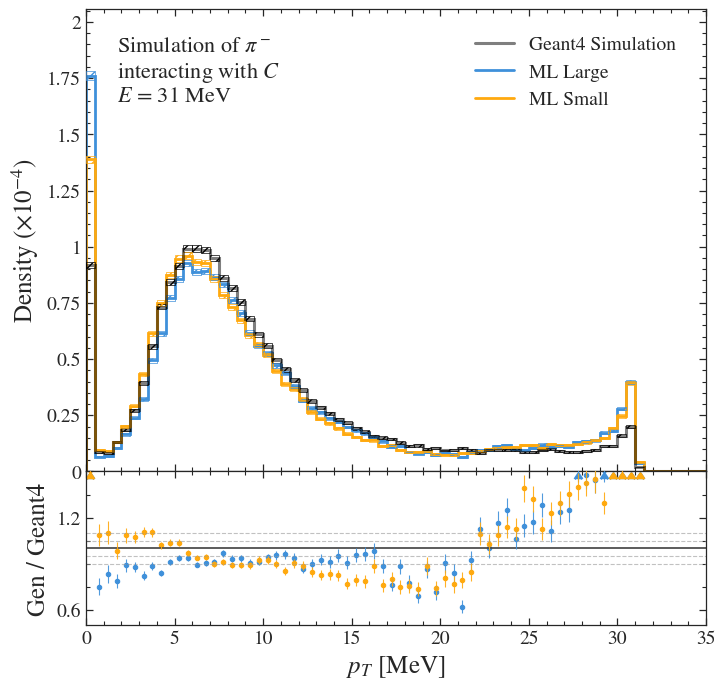

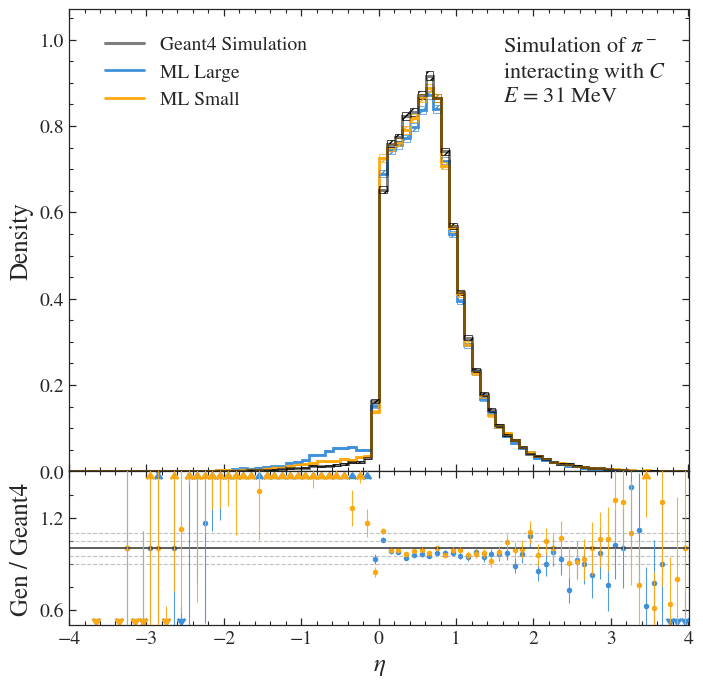

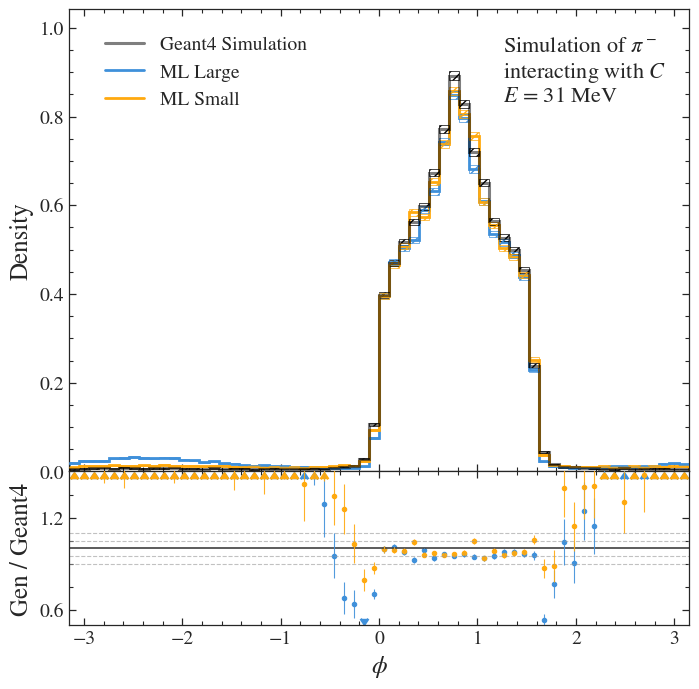

In [20]:
all_columns = ["pt", "eta", "phi"]
models_legend_titles = ['Geant4 Simulation', 'ML Large', 'ML Small']


cn_data_dict = {}
for column_name in all_columns:
    # analysis_v2.dataset provides methods to easily extract a single column for analysis
    gen_data_dict = {}
    pdata_real = analv2.dataset.extract_single_column_for_analysis(real_verbose_data, column_name, return_only_leading=True)
    for mn in models_to_compare:
        pdata_gen = analv2.dataset.extract_single_column_for_analysis(gen_verbose_data_dict[mn], column_name, return_only_leading=True)
        gen_data_dict[mn] = pdata_gen
        
    cn_data_dict[column_name] = (pdata_real, gen_data_dict)
    
# Table by default has three rows: [Generator Name, Codebook Size, N data plotted]
spec_table_rows = [
    ("Geant4", "-", numerize.numerize(len(pdata_real))),
    ("ML Large", "14.7k", numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))),
    ("ML Small", "1.9k", numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))),
]

# pt
cn = 'pt'
fig_r1_pt_leading_part, _ = analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=True,
    # spec_text=spec_text,
    # spec_table_rows=spec_table_rows,
    label_text=label_text,
    override_label_loc=(0.05, 0.80),
)

cn = 'eta'
fig_r1_eta_leading_part, _ = analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=True,
    show_legend=True,
    # spec_text=spec_text,
    # spec_table_rows=spec_table_rows,
    label_text=label_text,
    override_label_loc=(0.7, 0.80),
)

cn = 'phi'
fig_r1_phi_leading_part, _ = analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=True,
    show_legend=True,
    # spec_text=spec_text,
    # spec_table_rows=spec_table_rows,
    label_text=label_text,
    override_label_loc=(0.7, 0.80),
)

In [14]:
fig_r1_pt_leading_part.savefig("figures_export/png/pub_1_r1_pt_leading_part.png", bbox_inches='tight')
fig_r1_eta_leading_part.savefig("figures_export/png/pub_1_r1_eta_leading_part.png", bbox_inches='tight')
fig_r1_phi_leading_part.savefig("figures_export/png/pub_1_r1_phi_leading_part.png", bbox_inches='tight')

fig_r1_pt_leading_part.savefig("figures_export/pdf/pub_1_r1_pt_leading_part.pdf", bbox_inches='tight')
fig_r1_eta_leading_part.savefig("figures_export/pdf/pub_1_r1_eta_leading_part.pdf", bbox_inches='tight')
fig_r1_phi_leading_part.savefig("figures_export/pdf/pub_1_r1_phi_leading_part.pdf", bbox_inches='tight')

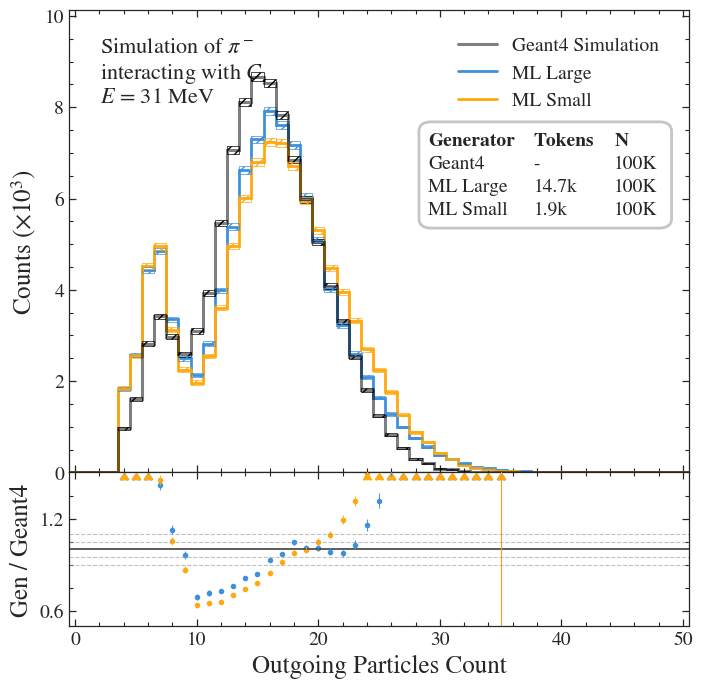

In [15]:
gen_data_dict = {}
pdata_real = analv2.dataset.extract_single_column_for_analysis(real_verbose_data, "num_particles")
for mn in models_to_compare:
    pdata_gen = analv2.dataset.extract_single_column_for_analysis(gen_verbose_data_dict[mn], "num_particles")
    gen_data_dict[mn] = pdata_gen

spec_text = (
    r"$ \bf{Geant4} $" "\n"
    f"   N: {numerize.numerize(len(pdata_real))}\n"
    r"$ \bf{ML \ Large} $" "\n"
     "   Codebook Size: 14.7k\n"
    f"   N: {numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))}\n"
    r"$ \bf{ML \ Small} $" "\n"
     "   Codebook Size: 1.9k\n"
    f"   N: {numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))}"
)

spec_table_rows = [
    ("Geant4", "-", numerize.numerize(len(pdata_real))),
    ("ML Large", "14.7k", numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))),
    ("ML Small", "1.9k", numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))),
]

fig_r1_num_part, (_) = analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name='num_particles',
    ref_vals=pdata_real,
    comp_vals_dict=gen_data_dict,
    model_legend_titles=models_legend_titles,
    density=False,
    use_log=False,
    out_file=None,
    title=None,
    # spec_text=spec_text,
    spec_table_rows=spec_table_rows,
    label_text=label_text,
    override_label_loc=(0.05, 0.80),
)

In [16]:
fig_r1_num_part.savefig("figures_export/pdf/pub_1_r1_num_part.pdf", bbox_inches='tight')
fig_r1_num_part.savefig("figures_export/png/pub_1_r1_num_part.png", bbox_inches='tight')

## <span style="color:#db7d60">Figure 4</span>

Validation loss curves for the two showcased models.

,compute_time_saved,compute_time_saved_days
0,1.041869e+08,1d 5h
1,1.655759e+08,1d 22h


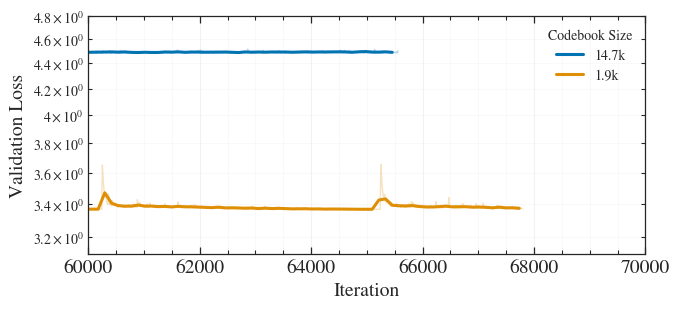

In [17]:
analv2.plotting_v2.fontsize_ticks = 14
analv2.plotting_v2.fontsize_axes_labels = 14

def ms_to_days_hours(ms):
    total_hours = round(ms / 1000 / 60 / 60)
    print(total_hours)
    days = total_hours // 24
    hours = total_hours % 24
    
    if days > 0:
        return f"{days}d {hours}h"
    else:
        return f"{hours}h"

def ms_to_days_hours_vec(ms):
    arr = np.asarray(ms, dtype=float)

    total_hours = np.rint(arr / 1000 / 3600).astype(np.int64)
    days = total_hours // 24
    hours = total_hours % 24

    days_str = days.astype(str)
    hours_str = hours.astype(str)

    out = np.where(
        days > 0,
        np.char.add(np.char.add(np.char.add(days_str, "d "), hours_str), "h"),
        np.char.add(hours_str, "h"),
    )

    if np.isscalar(ms):
        return out.item()
    if isinstance(ms, pd.Series):
        return pd.Series(out, index=ms.index)
    return out

titles = ['14.7k', '1.9k']
models = ['model_10M_9_exp9_vdimlr_1', 'model_10M_12_inclrrestarts_3']

df = analv2.tables.get_default_df(models)
df['compute_time_saved_days'] = ms_to_days_hours_vec(df['compute_time_saved'])
display(df[['compute_time_saved', 'compute_time_saved_days']])

fig_loss_curve, ax = analv2.plotting_v2.plot_training_run(models, model_legend_title=titles, show_val_loss=True, use_log=True, y_lim=(3.1, 4.8), x_lim=(60000, 70000), show_output=False)
ax.legend(title="Codebook Size")
plt.show()

In [18]:
fig_loss_curve.savefig("figures_export/png/pub_1_r1_loss_curve.png", bbox_inches='tight')
fig_loss_curve.savefig("figures_export/pdf/pub_1_r1_loss_curve.pdf", bbox_inches='tight')